# Load and Basic Check

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/dwibon/Desktop/ISL-FingerSpell/dataset/training_data.csv')
print("Shape:", df.shape)
print("Expected: (13800, 127)")  # 23 signs × 300 × 2 people
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes.value_counts())

Shape: (13800, 127)
Expected: (13800, 127)

Columns: ['left_lm0_x', 'left_lm0_y', 'left_lm0_z', 'left_lm1_x', 'left_lm1_y', 'left_lm1_z', 'left_lm2_x', 'left_lm2_y', 'left_lm2_z', 'left_lm3_x', 'left_lm3_y', 'left_lm3_z', 'left_lm4_x', 'left_lm4_y', 'left_lm4_z', 'left_lm5_x', 'left_lm5_y', 'left_lm5_z', 'left_lm6_x', 'left_lm6_y', 'left_lm6_z', 'left_lm7_x', 'left_lm7_y', 'left_lm7_z', 'left_lm8_x', 'left_lm8_y', 'left_lm8_z', 'left_lm9_x', 'left_lm9_y', 'left_lm9_z', 'left_lm10_x', 'left_lm10_y', 'left_lm10_z', 'left_lm11_x', 'left_lm11_y', 'left_lm11_z', 'left_lm12_x', 'left_lm12_y', 'left_lm12_z', 'left_lm13_x', 'left_lm13_y', 'left_lm13_z', 'left_lm14_x', 'left_lm14_y', 'left_lm14_z', 'left_lm15_x', 'left_lm15_y', 'left_lm15_z', 'left_lm16_x', 'left_lm16_y', 'left_lm16_z', 'left_lm17_x', 'left_lm17_y', 'left_lm17_z', 'left_lm18_x', 'left_lm18_y', 'left_lm18_z', 'left_lm19_x', 'left_lm19_y', 'left_lm19_z', 'left_lm20_x', 'left_lm20_y', 'left_lm20_z', 'right_lm0_x', 'right_lm0_y', '

# Check for missing values

In [9]:
nulls = df.isnull().sum().sum()
print(f"Total NaN values: {nulls}")

if nulls > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("Clean — no missing values")

Total NaN values: 0
Clean — no missing values


# Class balance

label
A    600
B    600
C    600
D    600
E    600
F    600
G    600
I    600
K    600
L    600
M    600
N    600
O    600
P    600
Q    600
R    600
S    600
T    600
U    600
V    600
W    600
X    600
Z    600
Name: count, dtype: int64

Min samples: 600 | Max samples: 600


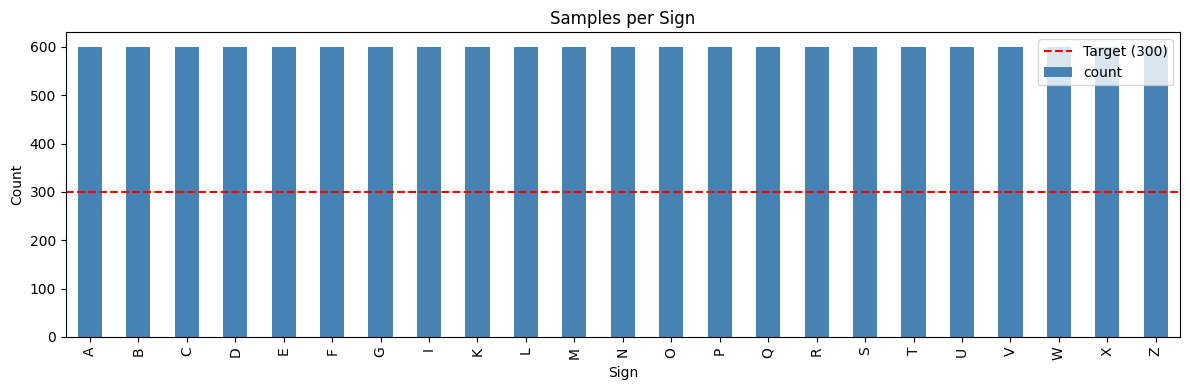

In [11]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts().sort_index()
print(counts)
print(f"\nMin samples: {counts.min()} | Max samples: {counts.max()}")

counts.plot(kind='bar', figsize=(12, 4), color='steelblue')
plt.title('Samples per Sign')
plt.xlabel('Sign')
plt.ylabel('Count')
plt.axhline(y=300, color='red', linestyle='--', label='Target (300)')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/dwibon/Desktop/ISL-FingerSpell/assets/class_distribution.png', dpi=150)
plt.show()

Check feature Ranges

In [12]:
# Features should be roughly -1 to 1 (wrist-relative normalised)
feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols]

print("Feature value ranges:")
print(f"Min: {X.min().min():.4f}")
print(f"Max: {X.max().max():.4f}")
print(f"Mean: {X.mean().mean():.4f}")

# Flag any suspiciously large values
outliers = (X.abs() > 2).sum().sum()
print(f"\nValues outside -2 to 2 range: {outliers}")

Feature value ranges:
Min: -0.4069
Max: 0.2855
Mean: -0.0323

Values outside -2 to 2 range: 0


 # Check zero values (failed two-hand captures)

In [13]:
# Rows where ALL left hand features are zero = left hand wasn't detected
left_cols = [c for c in df.columns if c.startswith('left_')]
right_cols = [c for c in df.columns if c.startswith('right_')]

left_zeros = (df[left_cols] == 0).all(axis=1).sum()
right_zeros = (df[right_cols] == 0).all(axis=1).sum()

print(f"Rows with no left hand detected: {left_zeros}")
print(f"Rows with no right hand detected: {right_zeros}")
print(f"Rows with neither hand detected: {((df[left_cols] == 0).all(axis=1) & (df[right_cols] == 0).all(axis=1)).sum()}")

Rows with no left hand detected: 3835
Rows with no right hand detected: 9
Rows with neither hand detected: 0
